## Projektziel

In unserem Projekt analysieren wir den Einfluss von Wetterbedingungen auf Flugverspätungen am Flughafen Wien (LOWW).

Die zentrale Fragestellung lautet:
Welche Wetterfaktoren haben tatsächlich einen messbaren Einfluss auf Verspätungen?

Dafür kombinieren wir Flugdaten mit Wetterdaten und untersuchen verschiedene Einflussgrößen wie Temperatur, Wind, Niederschlag und Schnee.

Ziel ist es, Zusammenhänge zu erkennen und herauszufinden, welche Faktoren besonders relevant sind.

In [ ]:
# 1. Imports & Setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient

# Für konsistente und gut lesbare Visualisierungen
sns.set(style="whitegrid")

## Datenbasis & Setup
- Flugdaten aus CSV (Jahr 2025)
- Wetterdaten aus CSV
- Speicherung in MongoDB (NoSQL-Datenbank)
- Analyse mit Pandas (Python)

Wir betrachten ausschließlich Flüge vom Flughafen Wien (LOWW).

Zur Vergleichbarkeit wird die Kennzahl "Verspätung pro Flug" berechnet:
delay_per_flight = Gesamtverspätung / Anzahl Flüge

In [ ]:
# 2. MongoDB-Verbindung herstellen

# Verbindung zu lokalem MongoDB-Server
client = MongoClient('mongodb://localhost:27017/')

# Datenbank auswählen
db = client['fluege_wetter']

# Collections definieren
flights_collection = db['flights']
weather_collection = db['weather']

# Vorhandene Collections anzeigen (Kontrolle)
print("Collections in der Datenbank:", db.list_collection_names())

Collections in der Datenbank: ['weather', 'flights']


## Datenverarbeitung
1. Daten laden und bereinigen
2. Speicherung in MongoDB für skalierbare Verarbeitung
3. Zusammenführen der Daten über das Datum
4. Berechnung der Kennzahl "delay_per_flight"

Diese Schritte ermöglichen eine effiziente Analyse und Vergleichbarkeit der Daten.

In [ ]:
# 3. Daten laden

# Flugdaten und Wetterdaten laden
flights = pd.read_csv('all_pre_departure_delays_2025.csv')
weather = pd.read_csv('weather.csv', decimal=',')

# Zeitspalten in echtes Datumsformat umwandeln
flights['scheduled_departure'] = pd.to_datetime(flights['FLT_DATE'])
weather['datetime'] = pd.to_datetime(weather['date'])

# NUR WIEN (LOWW) direkt nach dem Laden
flights = flights[flights['APT_ICAO'] == 'LOWW']

In [ ]:
# 4. Daten in MongoDB importieren

# Alte Daten löschen (damit keine Duplikate entstehen)
flights_collection.delete_many({})
weather_collection.delete_many({})

# Flugdaten (nur Wien) speichern
flights_collection.insert_many(flights.to_dict('records'))

# Wetterdaten vollständig speichern (werden später über Datum verknüpft)
weather_collection.insert_many(weather.to_dict('records'))

# Bestätigung
print("Daten erfolgreich in MongoDB importiert!")

Daten erfolgreich in MongoDB importiert!


In [ ]:
# 5. Daten aus MongoDB abrufen

# Flugdaten aus MongoDB laden und in DataFrame umwandeln
df_flights = pd.DataFrame(list(flights_collection.find()))

# Wetterdaten aus MongoDB laden
df_weather = pd.DataFrame(list(weather_collection.find()))

# MongoDB erzeugt automatisch eine _id-Spalte → für Analyse meist nicht notwendig
df_flights.drop(columns=['_id'], errors='ignore', inplace=True)
df_weather.drop(columns=['_id'], errors='ignore', inplace=True)

# Erste Zeilen prüfen (Kontrolle, ob Import funktioniert hat)
print("Flugdaten:")
print(df_flights.head())

print("\nWetterdaten:")
print(df_weather.head())

Flugdaten:
   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LOWW   Vienna    Austria   
1  2025          1       JAN  2025-01-02     LOWW   Vienna    Austria   
2  2025          1       JAN  2025-01-03     LOWW   Vienna    Austria   
3  2025          1       JAN  2025-01-04     LOWW   Vienna    Austria   
4  2025          1       JAN  2025-01-05     LOWW   Vienna    Austria   

   FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2 scheduled_departure  
0        253          253.0         3015.0          2025-01-01  
1        310          310.0         5975.0          2025-01-02  
2        335          335.0         5809.0          2025-01-03  
3        267          267.0         5214.0          2025-01-04  
4        302          302.0         8692.0          2025-01-05  

Wetterdaten:
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  \
0  2025-01-01 00:00:00  -3.4  -4.0  -2.8   0.0   NaN   NaN  14.7  27.8  

In [ ]:
# 6. Flugdaten & Wetterdaten zusammenführen

# Datum vereinheitlichen (nur Datum, kein Uhrzeitanteil)
df_flights['scheduled_departure'] = pd.to_datetime(df_flights['scheduled_departure']).dt.date
df_weather['datetime'] = pd.to_datetime(df_weather['datetime']).dt.date

# Merge über Datum
df_merged = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# unnötige Spalten entfernen
df_merged.drop(columns=['key_0'], errors='ignore', inplace=True)

# Verspätung pro Flug berechnen (vektorisiert, deutlich schneller als apply)
df_merged['delay_per_flight'] = df_merged['DLY_ALL_PRE_2'] / df_merged['FLT_DEP_1']

# Ergebnis prüfen
print("Zusammengeführte Daten:")
print(df_merged.round(2).head())

Zusammengeführte Daten:
   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LOWW   Vienna    Austria   
1  2025          1       JAN  2025-01-02     LOWW   Vienna    Austria   
2  2025          1       JAN  2025-01-03     LOWW   Vienna    Austria   
3  2025          1       JAN  2025-01-04     LOWW   Vienna    Austria   
4  2025          1       JAN  2025-01-05     LOWW   Vienna    Austria   

   FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  ... tmax prcp  snow  wdir  wspd  \
0        253          253.0         3015.0  ... -2.8  0.0   NaN   NaN  14.7   
1        310          310.0         5975.0  ... -0.4  NaN   NaN   NaN  17.4   
2        335          335.0         5809.0  ...  4.4  NaN   NaN   NaN  23.4   
3        267          267.0         5214.0  ...  3.1  0.0   NaN   NaN  18.0   
4        302          302.0         8692.0  ...  0.3  NaN   NaN   NaN  18.0   

   wpgt    pres   tsun    datetime  delay_per_flight  
0  27.8

## Analyse – Temperaturbereiche

Wir starten mit einer groben Einteilung der Temperaturen in Bereiche, um einen ersten Überblick zu bekommen.

### Interpretation
Man erkennt, dass besonders bei hohen Temperaturen über 20°C die Verspätungen deutlich ansteigen.  
Im mittleren Bereich zwischen 0 und 20°C sind die Verspätungen am geringsten.

Das deutet darauf hin, dass extreme Temperaturen den Flugbetrieb stärker beeinflussen.

Durchschnittliche Verspätung nach Temperaturbereich:
temp_range
(-10, 0]    11.34
(0, 10]     10.21
(10, 20]    12.29
(20, 30]    18.49
Name: delay_per_flight, dtype: float64


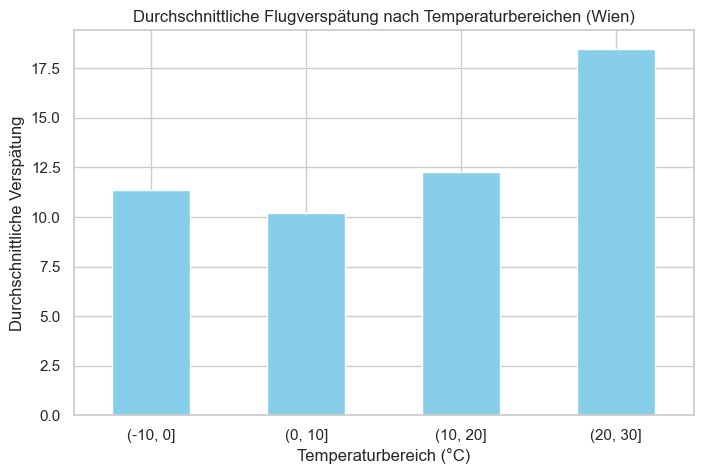

In [ ]:
# 7. Analyse: Durchschnittliche Verspätung nach Temperaturbereichen

# Temperaturbereiche definieren (°C)
temp_bins = [-10, 0, 10, 20, 30]
df_merged['temp_range'] = pd.cut(df_merged['tavg'], bins=temp_bins)

# Durchschnittliche Verspätung pro Temperaturbereich berechnen
avg_delay = df_merged.groupby('temp_range', observed=True)['delay_per_flight'].mean()

# Ausgabe
print("Durchschnittliche Verspätung nach Temperaturbereich:")
print(avg_delay.round(2))

# Visualisierung
avg_delay.plot(kind='bar', figsize=(8,5), color='skyblue')

plt.xlabel("Temperaturbereich (°C)")
plt.ylabel("Durchschnittliche Verspätung")
plt.title("Durchschnittliche Flugverspätung nach Temperaturbereichen (Wien)")
plt.xticks(rotation=0)
plt.show()

## Analyse – Windgeschwindigkeit (Scatterplot)

Als nächstes betrachten wir den direkten Zusammenhang zwischen Windgeschwindigkeit und Verspätung anhand eines Scatterplots.

### Interpretation
Die Punkte sind relativ zufällig verteilt und zeigen keinen klaren Trend.  
Das bedeutet, dass Windgeschwindigkeit allein keinen starken Einfluss auf die Verspätung hat.

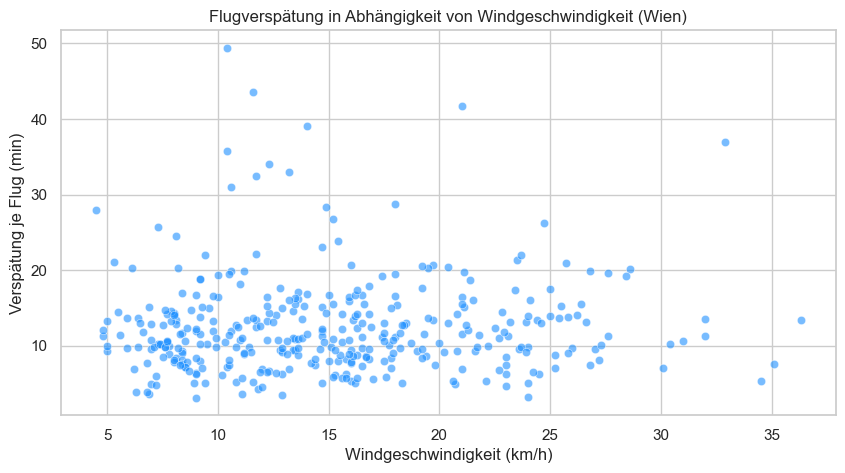

In [ ]:
# 8. Analyse: Flugverspätung in Abhängigkeit von Windgeschwindigkeit

# Sicherstellen, dass Flugdaten und Wetterdaten zusammengeführt sind
df_merged_wind = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# Verspätung pro Flug berechnen
# (Vermeidung von Division durch 0)
df_merged_wind['delay_per_flight'] = (
    df_merged_wind['DLY_ALL_PRE_2'] / df_merged_wind['FLT_DEP_1'].replace(0, pd.NA)
)

# Fehlende Windwerte behandeln (optional, aber stabiler für Plot)
df_merged_wind['wspd'] = df_merged_wind['wspd'].fillna(0)

# Scatterplot: Zusammenhang zwischen Wind und Verspätung
plt.figure(figsize=(10, 5))

sns.scatterplot(
    x='wspd',
    y='delay_per_flight',
    data=df_merged_wind,
    color='dodgerblue',
    alpha=0.6
)

# Achsenbeschriftungen und Titel
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Verspätung je Flug (min)")
plt.title("Flugverspätung in Abhängigkeit von Windgeschwindigkeit (Wien)")

plt.show()

## Analyse – Temperatur (detailliert)

Hier analysieren wir die Temperatur feiner aufgelöst, um genauere Trends zu erkennen.

### Interpretation
Es zeigt sich, dass die Verspätung mit steigender Temperatur tendenziell zunimmt.  
Besonders ab etwa 18–20°C steigen die Werte deutlich an.

Das bestätigt den vorherigen Eindruck aus den Temperaturbereichen.

Aggregierte Daten nach Temperatur:
    tavg  avg_delay
0     -4       9.26
1     -3      11.71
2     -2      12.20
3     -1      12.10
4      0      11.20
5      1      11.82
6      2      10.97
7      3      10.32
8      4       9.19
9      5      10.84
10     6       7.15
11     7       9.55
12     8       7.99
13     9      10.98
14    10      10.32
15    11      10.24
16    12      11.98
17    13      11.12
18    14       9.94
19    15      11.29
20    16      10.29
21    17      12.90
22    18      15.77
23    19      15.09
24    20      21.23
25    21      15.95
26    22      19.66
27    23      15.73
28    24      18.06
29    25      14.19
30    26      21.39
31    27      20.87


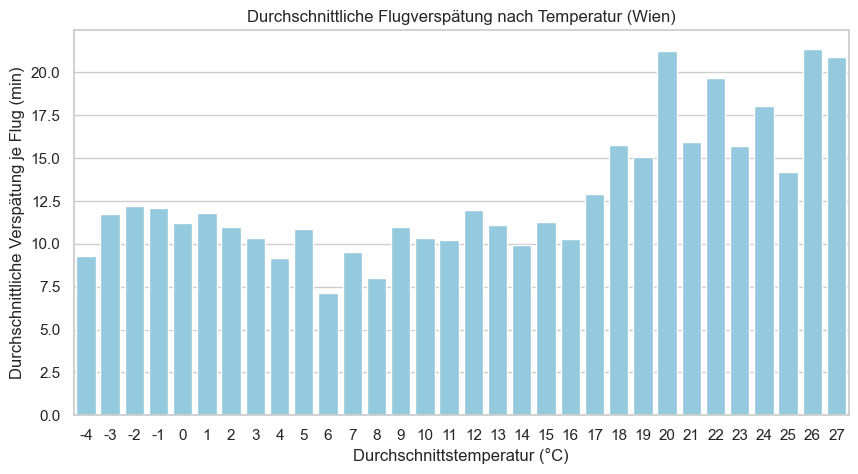

In [ ]:
# 9. Analyse: Durchschnittliche Verspätung nach Temperatur

# Pipeline definieren für Aggregation in MongoDB
pipeline_temp = [
    {
        "$lookup": {
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },
    {
        "$unwind": "$weather_info"
    },

    # Gruppieren nach Temperatur (abgerundet)
    {
        "$group": {
            "_id": { "$floor": "$weather_info.tavg" },
            "avg_delay": {
                "$avg": {
                    "$divide": ["$DLY_ALL_PRE_2", "$FLT_DEP_1"]
                }
            }
        }
    },

    {
        "$sort": { "_id": 1 }
    }
]

# Aggregation ausführen
result = list(flights_collection.aggregate(pipeline_temp))

# In DataFrame umwandeln
df_agg_temp = pd.DataFrame(result)
df_agg_temp.rename(columns={"_id": "tavg"}, inplace=True)

# X-Achse sauber machen (keine Nachkommastellen)
df_agg_temp["tavg"] = df_agg_temp["tavg"].astype(int)

# Ergebnis prüfen
print("Aggregierte Daten nach Temperatur:")
print(df_agg_temp.round(2))

# Visualisierung
plt.figure(figsize=(10,5))
sns.barplot(x="tavg", y="avg_delay", data=df_agg_temp, color='skyblue')

# Achsenbeschriftungen und Titel
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Durchschnittliche Verspätung je Flug (min)")
plt.title("Durchschnittliche Flugverspätung nach Temperatur (Wien)")
plt.show()

## Analyse – Niederschlag

Nun untersuchen wir den Einfluss von Niederschlag auf die Flugverspätungen.

### Interpretation
Mit zunehmendem Niederschlag steigen auch die durchschnittlichen Verspätungen.  
Das ist plausibel, da Regen die Sichtverhältnisse verschlechtert und Abläufe am Flughafen verlangsamt.

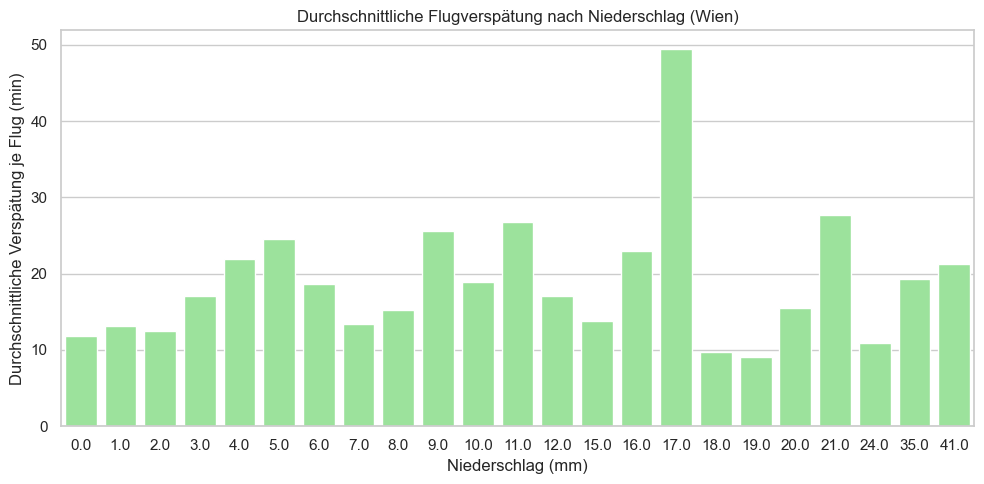

In [ ]:
# 10. Analyse: Durchschnittliche Flugverspätung nach Niederschlag

# Pipeline definieren für Aggregation in MongoDB
pipeline_prcp = [
    {
        "$lookup": {
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },

    # Weather-Array auflösen
    { "$unwind": "$weather_info" },

    # Gruppieren nach Niederschlag (abgerundet)
    {
        "$group": {
            "_id": { "$floor": "$weather_info.prcp" },
            "avg_delay": {
                "$avg": {
                    "$divide": ["$DLY_ALL_PRE_2", "$FLT_DEP_1"]
                }
            }
        }
    },

    # Sortieren nach Niederschlag
    {
        "$sort": { "_id": 1 }
    }
]

# Aggregation ausführen
result_prcp = list(flights_collection.aggregate(pipeline_prcp))

# In DataFrame umwandeln
df_prcp = pd.DataFrame(result_prcp)
df_prcp.rename(columns={"_id": "prcp"}, inplace=True)

# Visualisierung
plt.figure(figsize=(10,5))
sns.barplot(
    x="prcp",
    y="avg_delay",
    data=df_prcp,
    color='lightgreen'
)

# Achsenbeschriftungen und Titel
plt.xlabel("Niederschlag (mm)")
plt.ylabel("Durchschnittliche Verspätung je Flug (min)")
plt.title("Durchschnittliche Flugverspätung nach Niederschlag (Wien)")
plt.tight_layout()
plt.show()

## Analyse – Schnee

Für die Schneelage konnten keine aussagekräftigen Ergebnisse berechnet werden.

### Interpretation
Im Datensatz enthält die Variable "snow" für alle Tage ausschließlich fehlende Werte (NaN).  
Das bedeutet, dass keine Messwerte vorhanden sind und somit keine valide Analyse möglich ist.

Daher kann aus diesen Daten kein Zusammenhang zwischen Schneelage und Flugverspätung abgeleitet werden.

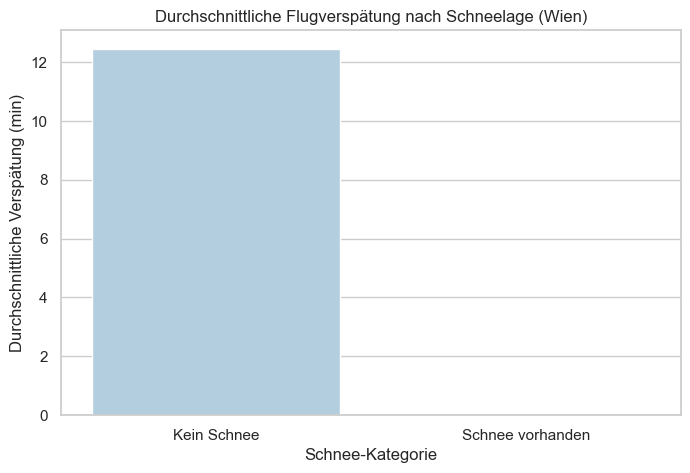

In [ ]:
# 11. Analyse: Durchschnittliche Flugverspätung nach Schneelage

# Schnee NaN -> 0 setzen
df_merged['snow'] = df_merged['snow'].fillna(0)

# Schnee-Kategorisierung
df_merged['snow_category'] = df_merged['snow'].apply(
    lambda x: 'Kein Schnee' if x == 0 else 'Schnee vorhanden'
)

# Durchschnittliche Verspätung berechnen
avg_delay_snow = (
    df_merged
    .groupby('snow_category')['delay_per_flight']
    .mean()
    .reset_index()
)

# Sicherstellen, dass beide Kategorien existieren
all_categories = ['Kein Schnee', 'Schnee vorhanden']
avg_delay_snow = (
    avg_delay_snow
    .set_index('snow_category')
    .reindex(all_categories)
    .reset_index()
)

# Visualisierung
plt.figure(figsize=(8, 5))

sns.barplot(
    x='snow_category',
    y='delay_per_flight',
    data=avg_delay_snow,
    hue='snow_category',   # wichtig wegen FutureWarning
    palette='Blues',
    legend=False
)

# Achsenbeschriftungen und Titel
plt.xlabel("Schnee-Kategorie")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Schneelage (Wien)")
plt.show()

## Analyse – Wind (aggregiert)

Zur Absicherung betrachten wir Wind nochmals in aggregierter Form.

### Interpretation
Auch hier zeigt sich kein klarer Zusammenhang zwischen Wind und Verspätung.  
Das bestätigt, dass Wind im Vergleich zu anderen Faktoren eine eher geringe Rolle spielt.

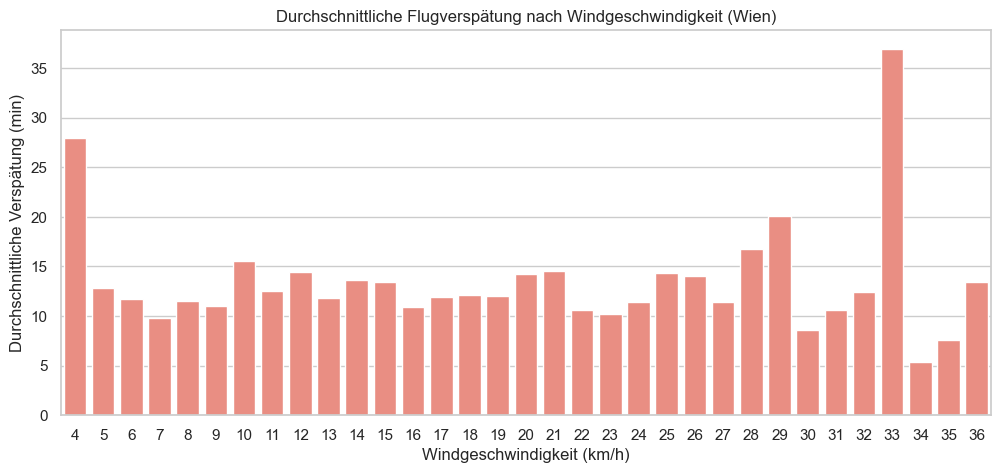

In [ ]:
# 12. Analyse: Durchschnittliche Flugverspätung nach Windgeschwindigkeit

# Merge direkt durchführen
df_merged_copy = pd.merge(
    df_flights,
    df_weather.assign(wspd=df_weather['wspd'].fillna(0)),
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# Verspätung berechnen
df_merged_copy['delay_per_flight'] = (
    df_merged_copy['DLY_ALL_PRE_2'] / df_merged_copy['FLT_DEP_1']
)

# Windgeschwindigkeit runden
df_merged_copy['wspd_floor'] = df_merged_copy['wspd'].round(0).astype(int)

# Gruppieren
df_wind_plot = (
    df_merged_copy
    .groupby('wspd_floor')['delay_per_flight']
    .mean()
    .reset_index()
)

# Visualisierung
plt.figure(figsize=(12, 5))

sns.barplot(
    x='wspd_floor',
    y='delay_per_flight',
    data=df_wind_plot,
    color='salmon'
)

# Achsenbeschriftungen und Titel
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Windgeschwindigkeit (Wien)")
plt.show()

## Analyse – Monat

Zusätzlich analysieren wir die Verspätungen im Verlauf des Jahres.

### Interpretation
Die höchsten Verspätungen treten im Sommer auf, besonders im Juli.  
Das lässt sich durch eine Kombination aus hoher Auslastung und höheren Temperaturen erklären.

Ergebnis:
    month  delay_per_flight
0       1              9.75
1       2              7.56
2       3              6.82
3       4             10.17
4       5             10.16
5       6             15.59
6       7             20.26
7       8             15.46
8       9             14.58
9      10             14.12
10     11              9.79
11     12             14.71


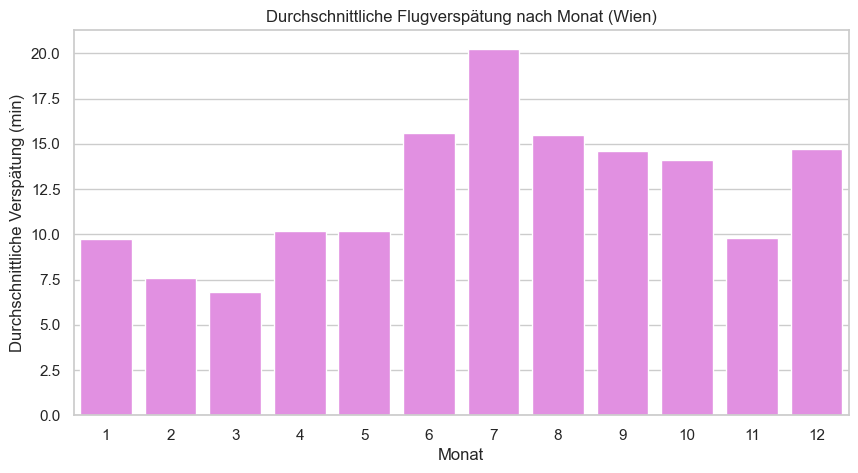

In [ ]:
# 13. Analyse: Durchschnittliche Flugverspätung pro Flug nach Monat

# Basisdaten (Flüge)
df_merged_monat = df_flights.copy()

# Datum in datetime umwandeln
df_merged_monat['scheduled_departure'] = pd.to_datetime(df_merged_monat['scheduled_departure'])

# Monat extrahieren
df_merged_monat['month'] = df_merged_monat['scheduled_departure'].dt.month

# Verspätung pro Flug berechnen (Division durch 0 vermeiden)
df_merged_monat['delay_per_flight'] = (
    df_merged_monat['DLY_ALL_PRE_2'] / df_merged_monat['FLT_DEP_1'].replace(0, pd.NA)
)

# monatlicher Durchschnitt
df_month_plot = (
    df_merged_monat
    .groupby('month')['delay_per_flight']
    .mean()
    .reset_index()
)

# Ergebnis ausgeben
df_month_plot = df_month_plot.round(2)
print("Ergebnis:")
print(df_month_plot)

# Visualisierung
plt.figure(figsize=(10, 5))

sns.barplot(
    x='month',
    y='delay_per_flight',
    data=df_month_plot,
    color='violet'
)

# Achsenbeschriftungen und Titel
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Monat (Wien)")

plt.show()

Ergebnis:
    month  avg_delay
0       1       9.75
1       2       7.56
2       3       6.82
3       4      10.17
4       5      10.16
5       6      15.59
6       7      20.26
7       8      15.46
8       9      14.58
9      10      14.12
10     11       9.79
11     12      14.71


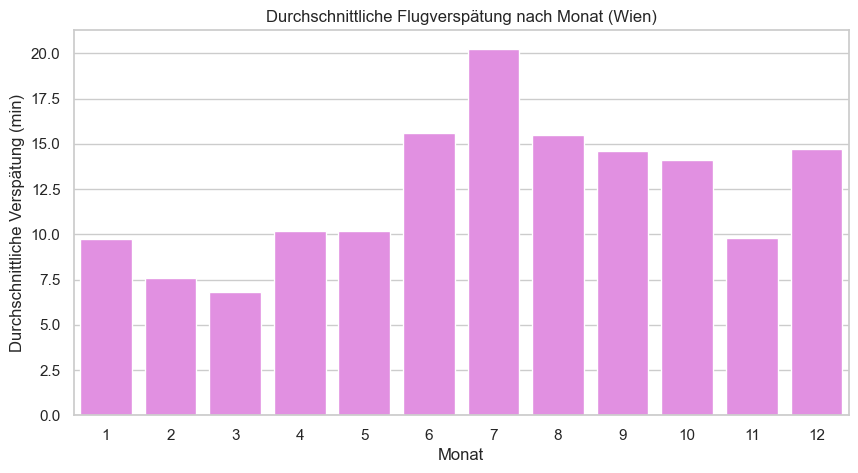

In [ ]:
# 14. Analyse: Durchschnittliche Verspätung nach Monat (Aggregation)

pipeline_month = [
    {
        "$project": {
            # Monat aus Datum extrahieren
            "month": { "$month": "$scheduled_departure" },

            # Verspätung pro Flug (normiert wie in allen anderen Analysen)
            "delay_per_flight": {
                "$cond": [
                    {
                        "$and": [
                            { "$gt": ["$FLT_DEP_1", 0] },
                            { "$ne": ["$DLY_ALL_PRE_2", None] }
                        ]
                    },
                    { "$divide": ["$DLY_ALL_PRE_2", "$FLT_DEP_1"] },
                    None
                ]
            }
        }
    },

    # Durchschnitt pro Monat
    {
        "$group": {
            "_id": "$month",
            "avg_delay": { "$avg": "$delay_per_flight" }
        }
    },

    # Sortierung
    {
        "$sort": { "_id": 1 }
    }
]

result = list(flights_collection.aggregate(pipeline_month))

# monatlicher Durchschnitt
df_month = pd.DataFrame(result).rename(columns={"_id": "month"})

# Ergebnis ausgeben
df_month = df_month.round(2)
print("Ergebnis:")
print(df_month)

# Visualisierung
plt.figure(figsize=(10,5))

sns.barplot(
    x="month",
    y="avg_delay",
    data=df_month,
    color="violet"
)

# Achsenbeschriftungen und Titel
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Flugverspätung nach Monat (Wien)")
plt.show()

## Vergleich der Methoden

**Pandas**: einfache, schnelle Analyse für kleinere Datenmengen  

**MongoDB Aggregation (MapReduce)**: skalierbar für große Datenmengen  

**Fazit:** Die Ergebnisse sind ähnlich, jedoch ist die MongoDB-Lösung besser für Big Data geeignet.

## Big Data Kriterien (5Vs)

**Volume:**
- Aktuell kleine bis mittlere Datenmengen (CSV-Dateien, Wetterdaten).  
- Infrastruktur erlaubt aber skalierbare Verarbeitung in MongoDB → geeignet für größere Datenmengen.

**2. Velocity:**  
- Daten stammen aus historischen Flugdaten → statisch.  
- Pipeline könnte aber für Echtzeit-Daten aus API erweitert werden (z.B. Live-Wetter oder Flüge).

**3. Variety:**  
- Zwei verschiedene Datenquellen: Flugdaten (CSV), Wetterdaten (CSV/API).  
- Daten enthalten unterschiedliche Formate: Datum, Temperatur, Niederschlag, Verspätung.

**4. Veracity:**  
- Flugdaten aus offizieller Quelle, Wetterdaten aus verlässlichem Open Data API.  
- Fehlende Werte wurden bereinigt (NaN → 0 oder kategorisiert).

**5. Value:**  
- Erkenntnisse über Einfluss von Wetter auf Flugverspätungen.  
- Möglichkeit, Vorhersagen oder Optimierungen für Flughafen Wien zu entwickeln.


## 4 Levels der Datenverarbeitung

**1. Data Source**  
- Flugdaten (CSV)  
- Wetterdaten (CSV)

**2. Data Storage**  
- MongoDB als NoSQL-Datenbank  
- Vorteil: einfache Aggregation, skalierbar für große Datenmengen, Multiuser-Zugriff

**3. Data Analysis**  
- Pandas: schnelle Analyse für kleine Datenmengen  
- MongoDB Aggregation (MapReduce): skalierbare Berechnung

**4. Data Output / Visualization**  
- Balkendiagramme für Durchschnittsverspätungen nach Temperatur, Wind, Niederschlag, Monat  
- Vergleich Pandas vs. MongoDB Aggregation zeigt Funktionsweise und Skalierbarkeit

## Infrastruktur & Architektur

**Architekturübersicht:**


In [ ]:
# Python Version:
import sys
print(f"Python Version: {sys.version}")

# Pandas Version:
import pandas as pd
print(f"Pandas Version: {pd.__version__}")

# Matplotlib Version:
import matplotlib
print(f"Matplotlib Version: {matplotlib.__version__}")

# Seaborn Version:
import seaborn as sns
print(f"Seaborn Version: {sns.__version__}")

# MongoDB-Version:
print(f"Matplotlib Version:") 
!mongod --version | head -n 1

Python Version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:13:31) [GCC 14.3.0]
Pandas Version: 3.0.1
Matplotlib Version: 3.10.8
Seaborn Version: 0.13.2
Matplotlib Version:
db version v7.0.31



**Details (23.04.2026):**
- **Python 3.13.12**
- **Pandas 3.0.1**
- **Matplotlib 3.10.8**
- **Seaborn 0.13.2**  
- **MongoDB 7.0.31** als NoSQL-Datenbank für skalierbare Speicherung  
- **Multiuser Setup:** GitHub Repository, Zugriff auf Notebook & Daten für das Team 

## Analyse – Korrelation

Zum Abschluss betrachten wir die Korrelation zwischen den Wetterfaktoren und den Verspätungen.

### Interpretation
Die stärksten Zusammenhänge sieht man bei Temperatur und Niederschlag.  
Wind hat nahezu keinen Einfluss, während Luftdruck sogar leicht negativ korreliert.

Damit werden die vorherigen Analysen nochmals bestätigt.

delay_per_flight    1.000000
tmin                0.407131
tavg                0.363098
prcp                0.333153
tmax                0.318629
tsun                0.150218
wpgt                0.065674
wspd                0.032993
pres               -0.238809
Name: delay_per_flight, dtype: float64


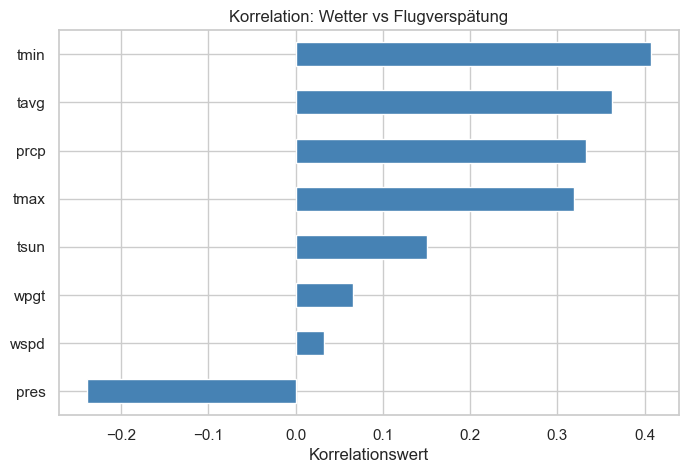

In [ ]:
# Korrelation zwischen Flugverspätung und Wetter

weather_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'wpgt', 'pres', 'tsun']

corr = df_merged[weather_cols + ['delay_per_flight']].corr()

print(corr['delay_per_flight'].sort_values(ascending=False))
corr_values = df_merged[weather_cols].corrwith(df_merged['delay_per_flight']).sort_values()

corr_values.plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Korrelation: Wetter vs Flugverspätung')
plt.xlabel('Korrelationswert')
plt.show()

## Methodik

Für die Analyse wurden zwei Datenquellen verwendet:
- Flugdaten aus einer CSV-Datei
- Wetterdaten aus einer CSV-Datei

Beide Datensätze wurden zunächst bereinigt, zeitlich vereinheitlicht und anschließend über das Datum zusammengeführt.

Zur Vergleichbarkeit der Tage mit unterschiedlich vielen Flügen wurde die Kennzahl "Verspätung pro Flug" berechnet:

delay_per_flight = DLY_ALL_PRE_2 / FLT_DEP_1

Die Auswertung erfolgte mit zwei Ansätzen:
- Pandas für die direkte Analyse in Python
- MongoDB Aggregation als MapReduce-nahe, skalierbare Verarbeitung

## Limitationen

Die Analyse basiert auf historischen Daten aus dem Jahr 2025 und ist daher zeitlich begrenzt.

Außerdem enthalten manche Variablen fehlende Werte. Besonders die Variable "snow" enthält im Datensatz ausschließlich NaN-Werte, weshalb dazu keine verlässliche Aussage getroffen werden kann.

Zusätzlich wurden nur Wetterfaktoren betrachtet. Andere mögliche Ursachen für Flugverspätungen, wie hohes Flugaufkommen, technische Probleme, Streiks oder betriebliche Abläufe, wurden nicht berücksichtigt.

Die Ergebnisse zeigen daher statistische Zusammenhänge, aber keine eindeutigen Ursache-Wirkungs-Beziehungen.

## Multiuser-Setup und Zusammenarbeit

Das Projekt wurde teamfähig aufgebaut.

Alle Teammitglieder haben Zugriff auf:
- den Jupyter-Notebook-Code
- die verwendeten Datensätze
- die MongoDB-Datenbank
- das GitHub-Repository zur gemeinsamen Versionierung

Dadurch ist die Infrastruktur multiuser-fähig und entspricht den Anforderungen der Aufgabenstellung.

## Ausblick

In Zukunft könnte das Projekt erweitert werden durch:
- Echtzeit-Wetterdaten über eine API
- zusätzliche Flugdatenquellen
- weitere Einflussfaktoren wie Flugaufkommen oder Tageszeit
- Machine-Learning-Modelle zur Vorhersage von Verspätungen

Dadurch könnten noch genauere Analysen und Prognosen erstellt werden.

## Fazit

Die Analyse zeigt, dass Wetterbedingungen einen klar messbaren Einfluss auf Flugverspätungen haben.

Besonders entscheidend sind Temperatur und Niederschlag:
- Hohe Temperaturen führen zu deutlich mehr Verspätungen
- Auch Regen und Schnee erhöhen die Verzögerungen im Flugbetrieb

Im Gegensatz dazu hat Wind nur einen sehr geringen Einfluss.

Zusätzlich zeigt die zeitliche Analyse, dass die Verspätungen vor allem im Sommer am höchsten sind, was auf eine Kombination aus hoher Auslastung und ungünstigen Wetterbedingungen zurückzuführen ist.

Insgesamt lässt sich sagen, dass vor allem extreme Wetterlagen den Flugverkehr negativ beeinflussen und zu erhöhten Verspätungen führen.